In [1]:
import dionysus as d
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
import numpy as np

import networkx as nx
from collections import defaultdict, Counter
import itertools
from itertools import combinations

from KK_zz_apex_LS import *
from helper_functions import *
from datasets import load_dataset, Features, Value
import pickle 
from collections import defaultdict
import sys
import json


In [17]:
# sequences = ["tagagatgcaacaatgggccgggacccgtgggccggcccgggcccatcctgatatagtgacgggccgggccaacatgacccgacactgtttaaggcacagcccagcccataaatattggtgggctgggctgggctaacctatatcggcctatgggccggcccgtgaaaaatcatgggttaggccgggcttgggccggcccgtctaggcccataatggctcggcctaaacaggcccgtctaagcccacaatgggccggcccagatgggcccgtttaggcccactataggccggccgagcaaaattattgatagacgtgttttgtttctaagaggtaaaattgatactgtaagtcatgtattatcacatcaaaatactatacatctaatatatatatatatataattattttgtgggagaaagaaagaggaagttgtctggaaaagagaaaaaattattgtttggaaaataatgttgcgtccgtggtgtgggaacgaaattttggaagtactgatactctgatagtagagtgataggcgacagcacgtcaaatgaattacgtttatccaagtgcctaacaaccttgcctatataataataataataataataataataatatttttgtaaagtgataggcggcagcacaatgaattacgtttaatatatatatatatataatatttttgtgaagtgataggcagcagcacgaattacgtttaatatatatatataataataatatttttgtgtgagaaagagagagagacttgctgaxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxgggaaagagagactgatatggcacttcatgaagtgataggacgtgcaaattgcaataaacgttagggatgtgcttccatcttagtttttgcctatatataaccgtggaaacgttgtggatgttgcagacgtgcttccatcttaattttagctttttattagttgacagttcttccgaaaggaaaaaaaaacttacaagtataatttatttcatttgttgttcattaattttatattgttataagttaattttattgtgtaattatcttatttaatttttattaatagtgttatgttaatttattgttattttttttattgaagtaatgacatcatcacatggaaggaacaccaatgtttcaaatttggtgatcaatgaagaagaacaatttaatgatccacttgaagaaattggagttgactcattatctcaagttggtggctcctctgatgtgactcgtaaaggtaaaagaaaaatgcaacgaacttcaccagtttagagttattttgatttggtaatgcgtaaaaatgagaatggtgtaatagaagaacatgcaatttgcaaagtatgcaaacaagactacacaggtaaatcctcttttggtactggtcacttagagaggcatcgcaaaaagtgcgaagctaagcatggtgtaggtggtgttgattgtcgtcaacaaacacttcaatttagctcttatggtagtgttatcaattggtcatatgaccaacaaagagctagagaatggcacgctagatatttggctattgctcaacaaccaattagtcttgctgatgatccggcctttgaggagtacattcaaaatgcttataatccacaatataggcgtgtttcaagaactgccacaagagctgacactatgaaagtatttcattcaatgagggaaaatttagttaatgaatttagttcattcactgcatatgttgcatgcacatctgatttgtgggaaggtcgcaccaaaactagttatatatgtgtaacggtacattatgtggataaagattgatcatttcaaaaaaggttaattgcttttcgatcaatgccttatccacattatgccaaggccattcatgatgtcatcatagaagtttttgatttttatggcattaaagaaaaggttttgagcatcacatttgacaatgcatctactaatactgctacgataaaccttttcaagacaactttgaaaccacaacatggtggaacactttttcaccaaagatgtacttgtcatattattaacttgtgcattcaagatggcatgaaattttttcaaggttatttggaaaatattcgaatggccttgggttacatagtaagttctggctcttgaattgaagaatttgctaaactttgcaagagagcaagcatgaaacccataaaacttcctactgacgtgggacaccgatggaattcaacatatttgatgttgaacgcatgcctaccatacaaagaggtcataaccgcgtatcacaacttgaagaatccaactgaaccgcttcaagaaattgattggcaaattgcttcatgcttctgtaatttcttgaaggttttttatgaagccactttccaactttcaggtgtgtactatcccacctctcctcatgcattacataaattgtacgacattgctgtaaccttcgatatgcatagagattttgacatgtttagggaatctgttgagttcatggaacaaaaattcaaaaaatattcagagcgtgttccatttttgtactgtgtagccgctgtattggatctaagagttaagttagctggtgttgaatatttgcttaagggtataggagaaaaactgaaggtgcattctgacatcataaccattcaaaatgtgcaagtaaaagttaacactttatttaccgcatataatgaaaaatatggaggaggccaaacaatgtcctctacacctttagtgagtactacatctttaccacatggttcttcaagggaaagtatgattagctacaccagatttggtttcggtgtgtcatccacatcttcagcacgtagtgaattggaaaactatctggaaacaaattttgcggcattcattttcaatgagcaaagtggtggtcatgatttcaatgagtttgatattttgtcattttggagatcacagttaagaacttttcccgtgctctctagaatggcgcgtgatatactaaccataccagtgtccacagttgcaagtgaacaagtatttagttgcagtggtagagtacttgatgaacggtgtgcacgcttgagtgacgatattctggaggcagtaatgtgcgtcaaagattgggaggacgctcgcagaagaagccaacaagttcaagatgattgggttgataattttgaaaatttagacatttctgatactcccactgggtgtaatacattgtaattacgaacaatatctatttttttttatgttttttatgttttttatgtttttttctttgttttggtaattttgtaaacatcttatgtataattattctgattgtactctttttttcttactaaggttttatcccactgggttttccttggcaagatttttaatgaggcaatcgtaaataaaatatatcttttcatattcccattgactattcaaacatttatttttgttaacttgtttaaaaataaaaaaaattaaaaattacatgcatagatgggctggcccatctaaacccatgatgggccaagataggccttgaatgggccagcccatctaaacccatgatgggctaatatgggccggcctattcaaggcccacggcacggcctgacctgggccacgacacgacctggcctggcccatgtaaagttggcacgtgggctgggccgggctgaggtaattcgtatatgggccggcctggcccagcccacataattggtgggccggcccggcccggcccacgtgggcctaagaagaacgggacgggctgagccggcccggcccgttcttgcatctcta"]
sequences = ["agctctcta"*10]
sequences = ["atgatatgatcat"]

a = ['a', 'c', 't', 'g', 'x']
k = 1
memory = 3

counter = 0

all_mappings = defaultdict(list)
zz_results = defaultdict(list)
all_barcodes = defaultdict(list)
dgms_all = defaultdict(list)
# all_sequences = {}

all_results = defaultdict(list)

for seq in sequences:
    
    # all_sequences[seq] = counter
    
    l = len(seq)
    print(f"Seq: {counter} Length: {l}")

    # TDA
    sorted_combos, node_id = get_alphabet(a, k)
    edges, nodes = get_edges(seq, k, node_id)

    simplicies = traverse_sequence(edges, memory)
    unionized = unionize_timepoints(simplicies)

    times_dict, self_edges = prep_simplicies(unionized)
    birth_death_times = get_birth_death_from_time_list(times_dict)
    simplices_final, times_final = prep_for_fastZZ(birth_death_times, node_id)
    cone, r, v, dgms = run_fastZZ(simplices_final,times_final)

    barcode_elements_H1, barcode_H1 = GetZZDionysus_H1(cone, r, v, dgms)

    all_results[seq].append({'barcode_elements_H1':barcode_elements_H1, 'barcode_H1':barcode_H1, 'dgms':dgms})

    counter += 1



Seq: 0 Length: 13


In [18]:
barcode_dict = defaultdict(list)

for cc, (b, d) in zip(barcode_elements_H1, barcode_H1):
    barcode_dict[cc].append(b)
    barcode_dict[cc].append(d)

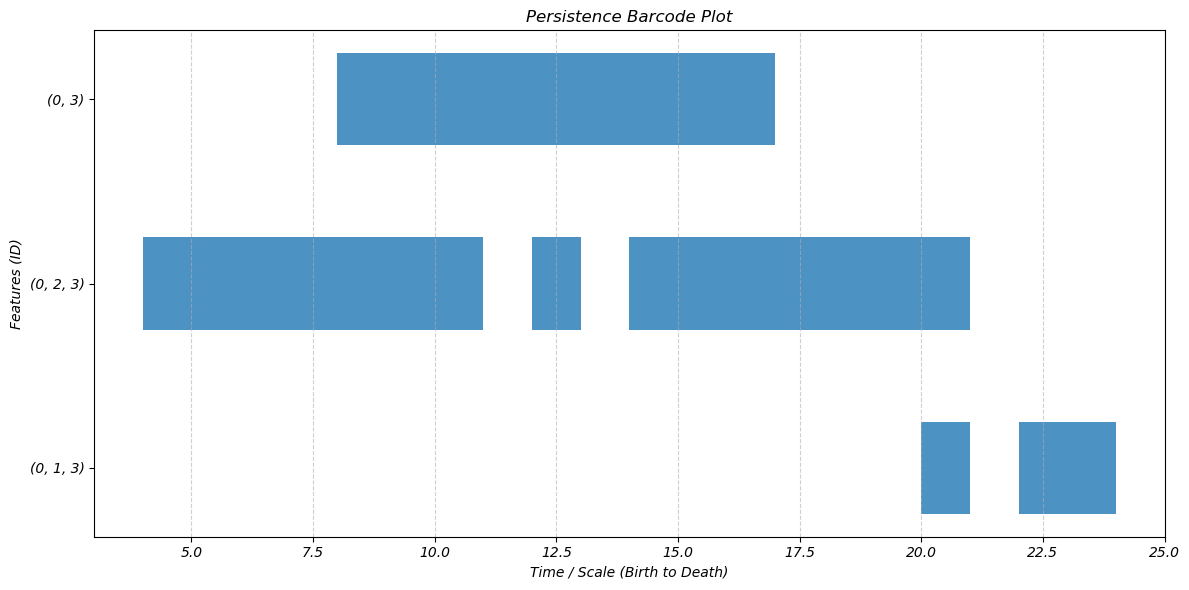

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort IDs to keep the Y-axis organized
sorted_ids = sorted(barcode_dict.keys())
y_positions = range(len(sorted_ids))

for i, label in enumerate(sorted_ids):
    values = barcode_dict[label]
    bars = []
    
    # Iterate through the list in steps of 2 to create (start, width) pairs
    for j in range(0, len(values) - 1, 2):
        birth = values[j]
        death = values[j+1]
        width = death - birth
        # broken_barh expects (start_x, width_x)
        bars.append((birth, width))
    
    # Plot the bars for this ID
    # (y_start, y_height) defines the vertical position and thickness
    ax.broken_barh(bars, (i - 0.25, 0.5), facecolors='tab:blue', alpha=0.8)

# Formatting the plot
ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_ids)
ax.set_xlabel('Time / Scale (Birth to Death)')
ax.set_ylabel('Features (ID)')
ax.set_title('Persistence Barcode Plot')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

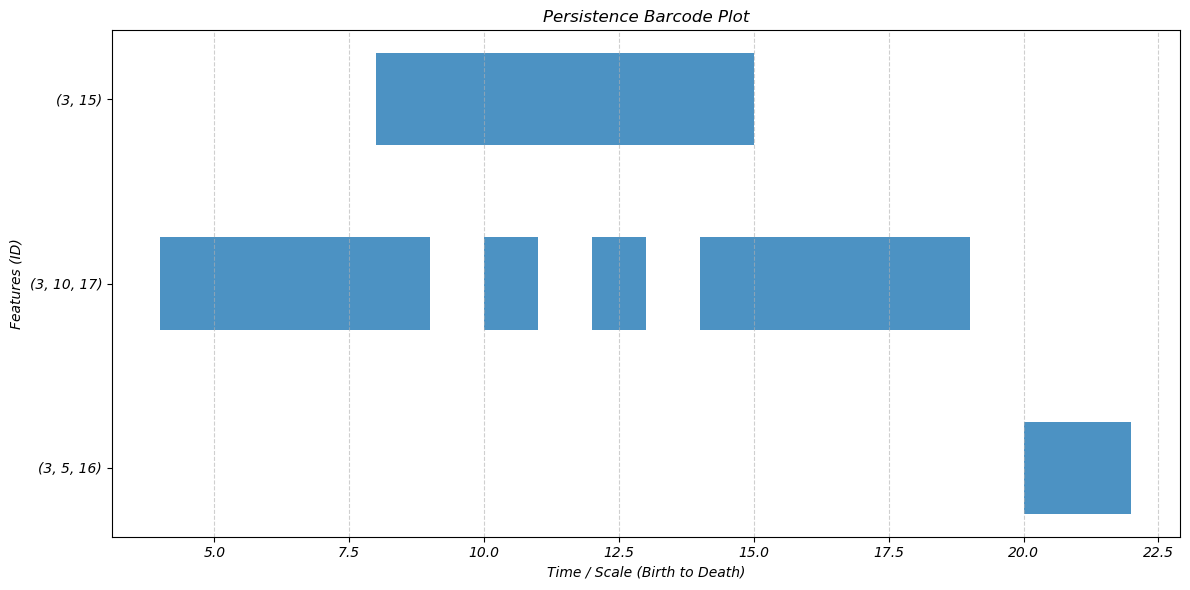

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort IDs to keep the Y-axis organized
sorted_ids = sorted(barcode_dict.keys())
y_positions = range(len(sorted_ids))

for i, label in enumerate(sorted_ids):
    values = barcode_dict[label]
    bars = []
    
    # Iterate through the list in steps of 2 to create (start, width) pairs
    for j in range(0, len(values) - 1, 2):
        birth = values[j]
        death = values[j+1]
        width = death - birth
        # broken_barh expects (start_x, width_x)
        bars.append((birth, width))
    
    # Plot the bars for this ID
    # (y_start, y_height) defines the vertical position and thickness
    ax.broken_barh(bars, (i - 0.25, 0.5), facecolors='tab:blue', alpha=0.8)

# Formatting the plot
ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_ids)
ax.set_xlabel('Time / Scale (Birth to Death)')
ax.set_ylabel('Features (ID)')
ax.set_title('Persistence Barcode Plot')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

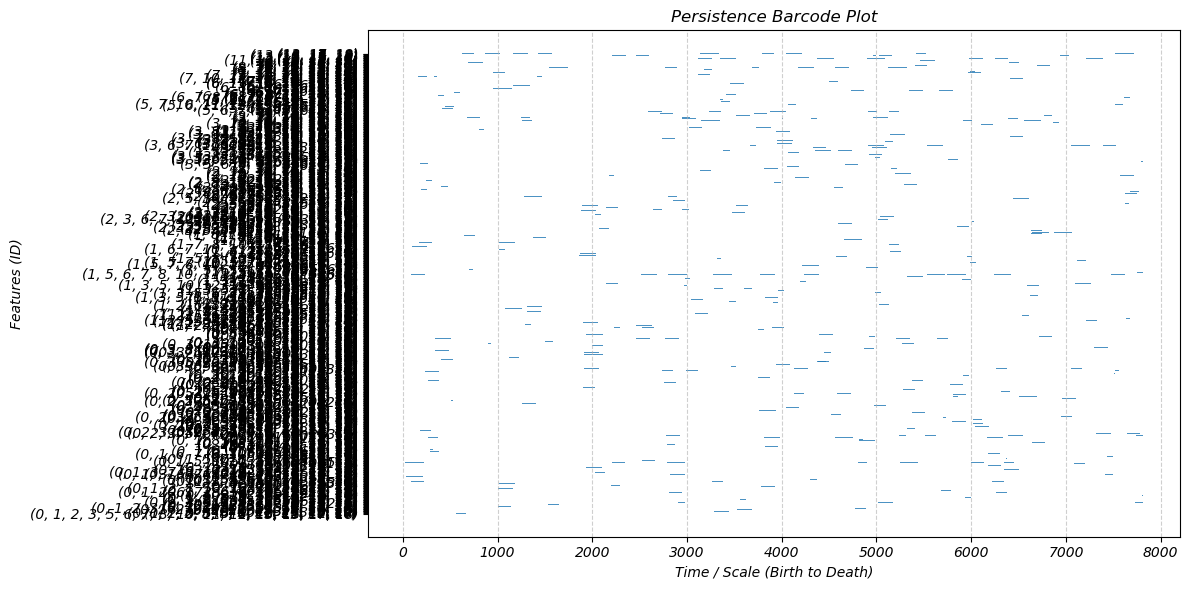

In [64]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort IDs to keep the Y-axis organized
sorted_ids = sorted(barcode_dict.keys())
y_positions = range(len(sorted_ids))

for i, label in enumerate(sorted_ids):
    values = barcode_dict[label]
    bars = []
    
    # Iterate through the list in steps of 2 to create (start, width) pairs
    for j in range(0, len(values) - 1, 2):
        birth = values[j]
        death = values[j+1]
        width = death - birth
        # broken_barh expects (start_x, width_x)
        bars.append((birth, width))
    
    # Plot the bars for this ID
    # (y_start, y_height) defines the vertical position and thickness
    ax.broken_barh(bars, (i - 0.25, 0.5), facecolors='tab:blue', alpha=0.8)

# Formatting the plot
ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_ids)
ax.set_xlabel('Time / Scale (Birth to Death)')
ax.set_ylabel('Features (ID)')
ax.set_title('Persistence Barcode Plot')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/var/folders/rs/jrxh2nk134sf41fhr94x81s80000gn/T/ipykernel_47024/696288533.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


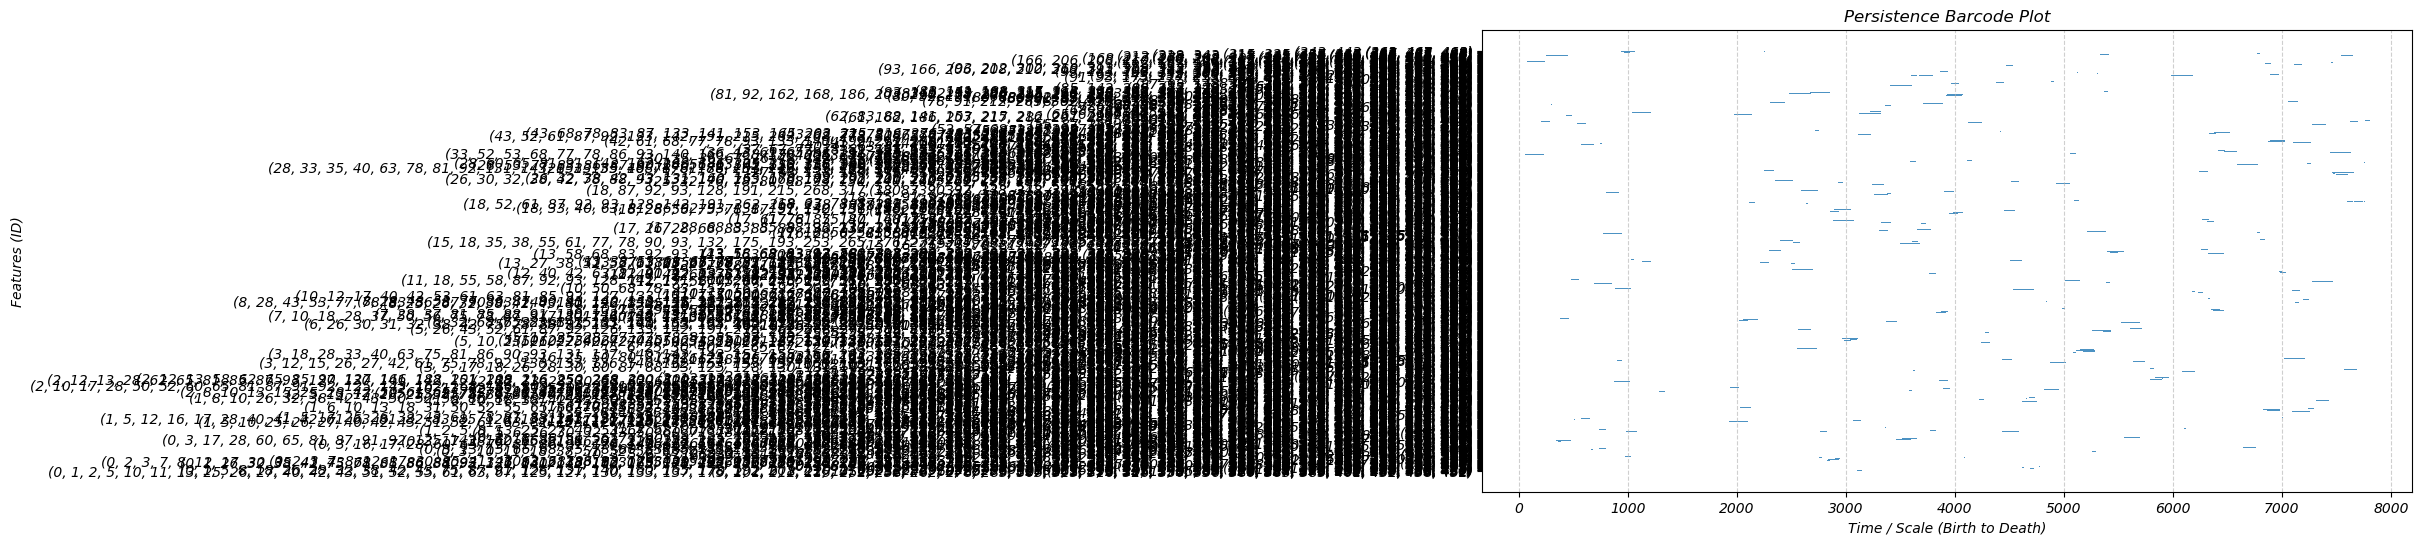

In [70]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort IDs to keep the Y-axis organized
sorted_ids = sorted(barcode_dict.keys())
y_positions = range(len(sorted_ids))

for i, label in enumerate(sorted_ids):
    values = barcode_dict[label]
    bars = []
    
    # Iterate through the list in steps of 2 to create (start, width) pairs
    for j in range(0, len(values) - 1, 2):
        birth = values[j]
        death = values[j+1]
        width = death - birth
        # broken_barh expects (start_x, width_x)
        bars.append((birth, width))
    
    # Plot the bars for this ID
    # (y_start, y_height) defines the vertical position and thickness
    ax.broken_barh(bars, (i - 0.25, 0.5), facecolors='tab:blue', alpha=0.8)

# Formatting the plot
ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_ids)
ax.set_xlabel('Time / Scale (Birth to Death)')
ax.set_ylabel('Features (ID)')
ax.set_title('Persistence Barcode Plot')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/var/folders/rs/jrxh2nk134sf41fhr94x81s80000gn/T/ipykernel_47024/696288533.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


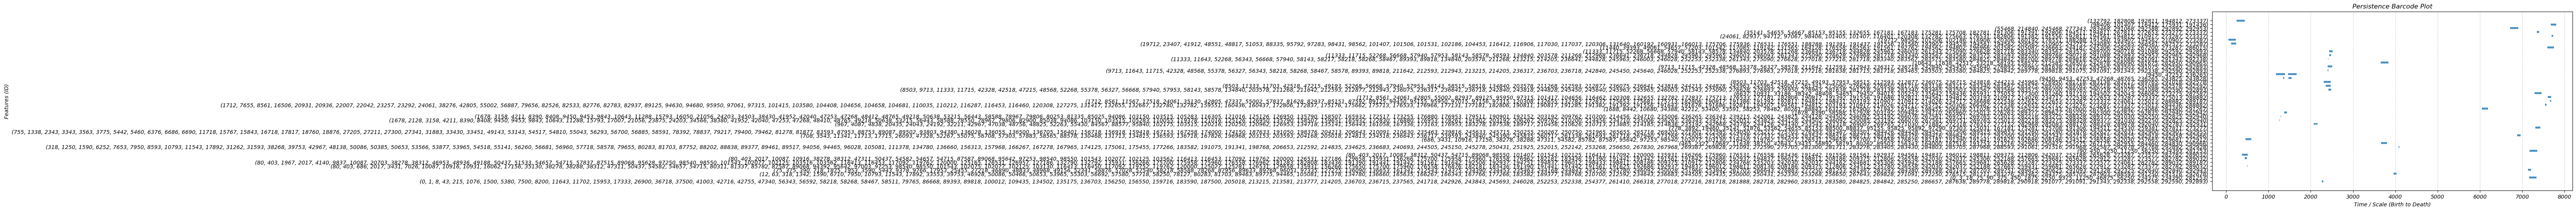

In [73]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort IDs to keep the Y-axis organized
sorted_ids = sorted(barcode_dict.keys())
y_positions = range(len(sorted_ids))

for i, label in enumerate(sorted_ids):
    values = barcode_dict[label]
    bars = []
    
    # Iterate through the list in steps of 2 to create (start, width) pairs
    for j in range(0, len(values) - 1, 2):
        birth = values[j]
        death = values[j+1]
        width = death - birth
        # broken_barh expects (start_x, width_x)
        bars.append((birth, width))
    
    # Plot the bars for this ID
    # (y_start, y_height) defines the vertical position and thickness
    ax.broken_barh(bars, (i - 0.25, 0.5), facecolors='tab:blue', alpha=0.8)

# Formatting the plot
ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_ids)
ax.set_xlabel('Time / Scale (Birth to Death)')
ax.set_ylabel('Features (ID)')
ax.set_title('Persistence Barcode Plot')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()